In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Задача иследовать data_additional/point_of_interest.csv

- читаю файл data_additional/point_of_interest.csv

In [2]:
point_of_interest = pd.read_csv('../../data_additional/point_of_interest.csv')
point_of_interest

,start_station_id,category,name_build,start_lat,start_lng
0,30200,place_of_worship,Methodist Protestant Church,38.896501,-77.024143
1,30200,kindergarten,Georgetown Hill Early Childhood Center,38.895100,-77.023200
2,30200,kindergarten,Just Us Kids Child Development Center,38.894600,-77.020700
3,30200,theatre,Shakespeare Theatre Company - Klein Theater,38.895734,-77.022132
4,30200,cafe,Gregorys Coffee,38.895972,-77.021713
...,...,...,...,...,...
34392,33200,bench,NaN,38.894267,-77.038270
34393,33200,bench,NaN,38.897443,-77.036620
34394,33200,bench,NaN,38.897445,-77.036499
34395,33200,bench,NaN,38.896953,-77.036979


- смотрю сколько уникальных станций

In [3]:
len(point_of_interest['start_station_id'].unique())

796

- делаю группировку по start_station_id и category и считаю колько получится category (отсортировал и вывел последние 30)

In [11]:
point_of_interest.groupby(['start_station_id', 'category'])['category'].count().sort_values(ascending=False).head(30)

start_station_id  category        
31248             bench               168
31117             bench               142
31257             bench               122
31261             bench               118
31015             parking_entrance    104
31231             bench                96
31247             bench                87
31633             bench                83
31275             bench                82
31947             parking_entrance     80
32600             bench                75
31253             bench                74
31222             bench                74
31236             bench                73
31335             bench                63
31203             bench                62
31205             bench                60
32083             waste_basket         60
31127             bench                59
31015             bicycle_parking      58
31613             restaurant           58
31027             bicycle_parking      58
31289             bench                57

- подготавливаю данные что бы построить график (pie) выбрал топ 10

In [12]:
share_point_of_interest = point_of_interest['category'].value_counts().iloc[:10]
share_point_of_interest

category
bench               6239
restaurant          4618
parking_entrance    3208
bicycle_parking     2756
fast_food           2426
waste_basket        2197
bicycle_rental      1672
cafe                1500
bank                1056
bar                  721
Name: count, dtype: int64

- построил график (pie) Доля точек интереса (топ 10)

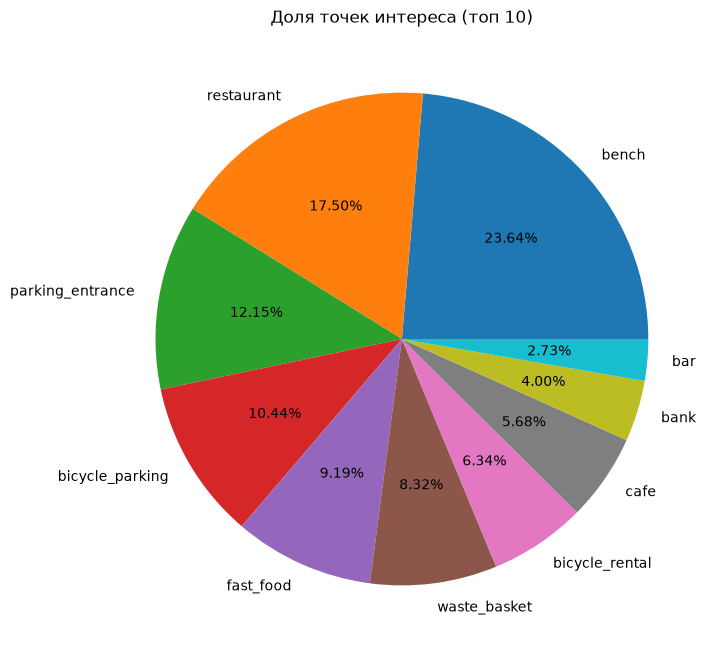

In [13]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.pie(
    share_point_of_interest.values,
    labels=share_point_of_interest.index,
    autopct='%1.2f%%',
    startangle=0
)

plt.title('Доля точек интереса (топ 10)')
plt.show()

- затем вывожу график по столбцу start_lat, что бы посмотреть что точки не находятся, где далеко от города 

<Axes: >

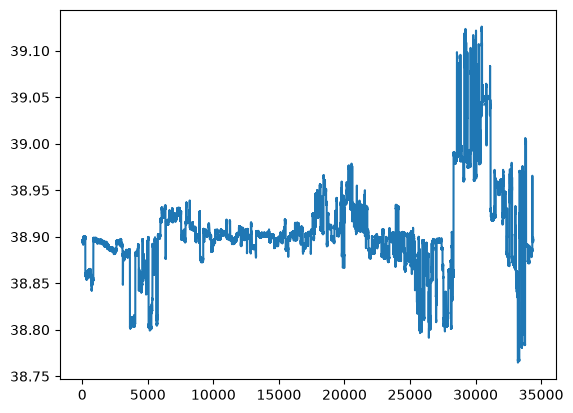

In [14]:
point_of_interest['start_lat'].plot()

- повторяю тоже самое со столбцом start_lng

<Axes: >

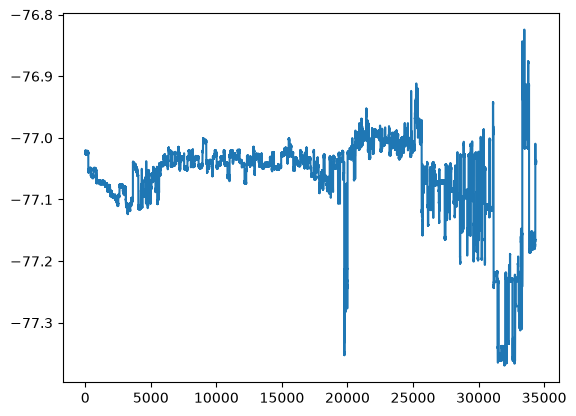

In [15]:
point_of_interest['start_lng'].plot()

- выбираю максимальные и минимальные точки

In [16]:
min_lat = point_of_interest['start_lat'].min()
max_lat = point_of_interest['start_lat'].max()

min_lng = point_of_interest['start_lng'].min()
max_lng = point_of_interest['start_lng'].max()

-вывожу результат

In [17]:
min_lat, max_lat

(np.float64(38.7646526), np.float64(39.1260151))

In [18]:
min_lng, max_lng

(np.float64(-77.3695595), np.float64(-76.824268))

## Вывод
- Точки интереса находятся в городе